In [4]:
!pip install scikeras
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.lines import Line2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.metrics import mean_absolute_error

In [6]:
# Load data
data = pd.read_csv("/content/Texas_Pasture_Agroecosystem_Dataset.csv")
# The 'Date' column, features, and target variables might differ in this new dataset.
# We will inspect the dataframe first to determine the correct columns.

# K-Fold setup (can remain, but will be applied after new features/targets are defined)
kf = KFold(n_splits=10, shuffle=True, random_state=50)

In [4]:
print(data.head())
print(data.info())

              Date  Soil moisture plot SorgT15  Soil moisture plot SorgT16  \
0   8/10/2023 8:00                    0.119429                    0.133057   
1   8/10/2023 8:30                    0.115642                    0.128593   
2   8/10/2023 9:00                    0.113464                    0.133820   
3   8/10/2023 9:30                    0.116525                    0.136278   
4  8/10/2023 10:00                    0.117856                    0.129714   

   NET_CARBON_DIOXIDE_FLUX       GPP      RECO  Sensible heat flux  \
0                -0.653472  3.773729  3.210141           90.622950   
1                 0.979899  2.307250  3.385468          209.385897   
2                -3.690773  7.666556  3.562899          235.871262   
3                -6.161308  9.701752  3.735863          241.594896   
4                -3.646955  7.268372  3.542634          243.887808   

   Evapotranspiration  Soil heat flux  Net radiation  ...  \
0            0.052024       19.200094     228.115

In [7]:
data['Date'] = pd.to_datetime(data['Date'])

features = ['Evapotranspiration', 'Soil heat flux', 'Air temperature', 'Rainfall',
            'RECO', 'Relative humidity', 'Air pressure', 'Wind speed', 'Wind direction']
target_train = 'Soil moisture plot SorgT15'
target_test  = 'Soil moisture plot SorgT16'

data_clean = data.dropna(subset=features + [target_train, target_test]).copy()
X = data_clean[features].values
y_train = data_clean[target_train].values
y_test  = data_clean[target_test].values
dates   = data_clean['Date'].values
# Feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# K-Fold setup
kf = KFold(n_splits=10, shuffle=True, random_state=50)

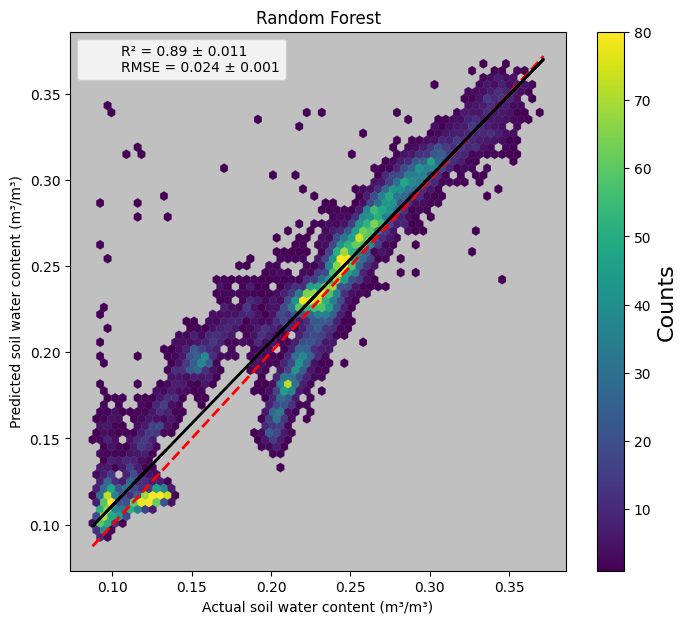

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, max_features=5, min_samples_split=5)

cv_r2_rf = cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_rf = np.sqrt(-cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rf = -cross_val_score(rf, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

rf.fit(X_scaled, y_train)
y_pred_rf = rf.predict(X_scaled)

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_rf, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.2, vmax=80)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts', fontsize=16)

ax.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_rf)
y_reg = reg.predict(y_test.reshape(-1,1))
ax.plot(y_test, y_reg, color='black', lw=2)

r2_mean, r2_std = cv_r2_rf.mean(), cv_r2_rf.std()
rmse_mean, rmse_std = cv_rmse_rf.mean(), cv_rmse_rf.std()

stats = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"
handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle],[stats],loc='upper left')
ax.set_title("Random Forest")
ax.set_xlabel("Actual soil water content (m³/m³)")
ax.set_ylabel("Predicted soil water content (m³/m³)")
plt.show()

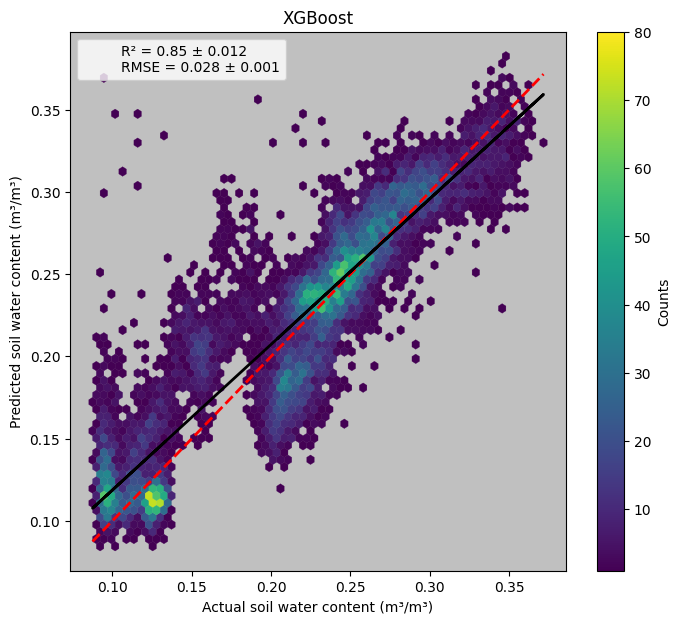

In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=140, max_depth=5, learning_rate=0.12, subsample=0.8, random_state=42)

cv_r2_xgb = cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_xgb = np.sqrt(-cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_xgb = -cross_val_score(xgb_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

xgb_model.fit(X_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_scaled)

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_xgb, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.2, vmax=80)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts')

ax.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_xgb)
ax.plot(y_test, reg.predict(y_test.reshape(-1,1)), color='black', lw=2)

stats = f"R² = {cv_r2_xgb.mean():.2f} ± {cv_r2_xgb.std():.3f}\nRMSE = {cv_rmse_xgb.mean():.3f} ± {cv_rmse_xgb.std():.3f}"
handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle],[stats],loc='upper left')
ax.set_title("XGBoost")
ax.set_xlabel("Actual soil water content (m³/m³)")
ax.set_ylabel("Predicted soil water content (m³/m³)")
plt.show()

In [11]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.0.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 38.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [1]:
!pip uninstall scikit-learn -y
!pip install scikit-learn

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)


In [8]:
def build_dnn():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.012), loss='mean_squared_error')
    return model

dnn_reg = KerasRegressor(model=build_dnn, epochs=120, batch_size=60, verbose=0)

cv_r2_dnn = cross_val_score(dnn_reg, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_dnn = np.sqrt(-cross_val_score(dnn_reg, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_dnn = -cross_val_score(dnn_reg, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

dnn_reg.fit(X_scaled, y_train)
y_pred_dnn = dnn_reg.predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

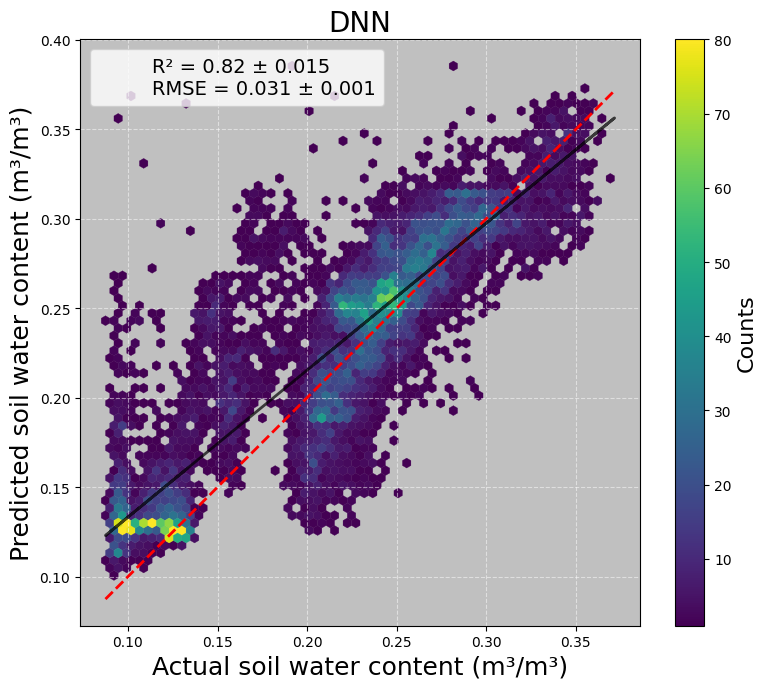

In [9]:
# ================= DNN PLOT =================

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_dnn,
               gridsize=60,
               cmap='viridis',
               mincnt=1,
               linewidths=0.2,
               vmax=80)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts', fontsize=16)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

# regression line
reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_dnn)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7)

# metrics
r2_mean, r2_std = cv_r2_dnn.mean(), cv_r2_dnn.std()
rmse_mean, rmse_std = cv_rmse_dnn.mean(), cv_rmse_dnn.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle], [stats_text], loc='upper left', fontsize=14)

ax.set_title("DNN", fontsize=20)
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=18)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=18)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.show()

In [10]:
def build_lstm():
    model = Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(1, X_scaled.shape[1])),
        Dropout(0.2),
        LSTM(64, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.012), loss='mean_squared_error')
    return model

X_scaled_lstm = X_scaled.reshape((X_scaled.shape[0],1,X_scaled.shape[1]))

lstm_reg = KerasRegressor(model=build_lstm, epochs=120, batch_size=60, verbose=0)

cv_r2_lstm = cross_val_score(lstm_reg, X_scaled_lstm, y_train, cv=kf, scoring='r2')
cv_rmse_lstm = np.sqrt(-cross_val_score(lstm_reg, X_scaled_lstm, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_lstm = -cross_val_score(lstm_reg, X_scaled_lstm, y_train, cv=kf, scoring='neg_mean_absolute_error')

lstm_reg.fit(X_scaled_lstm, y_train)
y_pred_lstm = lstm_reg.predict(X_scaled_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

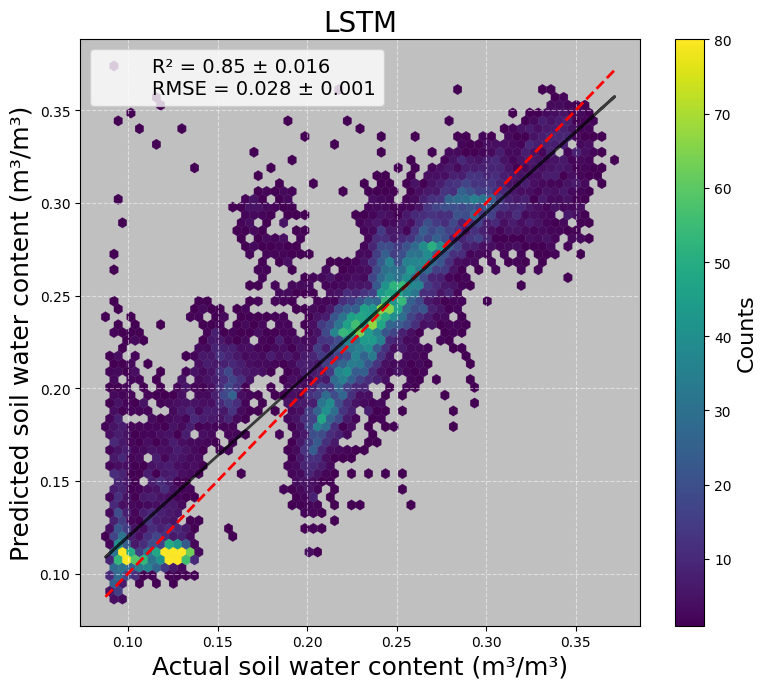

In [11]:
# ================= LSTM PLOT =================

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_lstm,
               gridsize=60,
               cmap='viridis',
               mincnt=1,
               linewidths=0.2,
               vmax=80)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts', fontsize=16)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

# regression line
reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_lstm)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7)

# metrics
r2_mean, r2_std = cv_r2_lstm.mean(), cv_r2_lstm.std()
rmse_mean, rmse_std = cv_rmse_lstm.mean(), cv_rmse_lstm.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle], [stats_text], loc='upper left', fontsize=14)

ax.set_title("LSTM", fontsize=20)
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=18)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=18)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.show()

In [12]:
ann_model = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu',
                         solver='adam', learning_rate='adaptive',
                         learning_rate_init=0.003, max_iter=1000,
                         early_stopping=True, random_state=42)

cv_r2_ann = cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_ann = np.sqrt(-cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_ann = -cross_val_score(ann_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

ann_model.fit(X_scaled, y_train)
y_pred_ann = ann_model.predict(X_scaled)

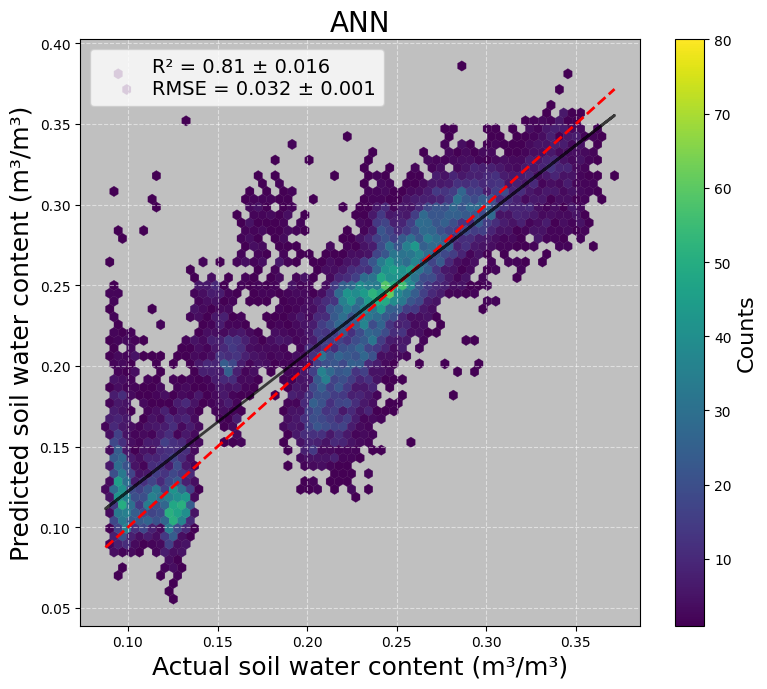

In [13]:
# ================= ANN PLOT =================

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_ann,
               gridsize=60,
               cmap='viridis',
               mincnt=1,
               linewidths=0.2,
               vmax=80)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts', fontsize=16)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

# Regression line
reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_ann)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7)

# Metrics
r2_mean, r2_std = cv_r2_ann.mean(), cv_r2_ann.std()
rmse_mean, rmse_std = cv_rmse_ann.mean(), cv_rmse_ann.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')
ax.legend([handle], [stats_text], loc='upper left', fontsize=14)

ax.set_title("ANN", fontsize=20)
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=18)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=18)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.show()

In [ ]:
svm_model = SVR(kernel='rbf', C=60, epsilon=0.0001, degree=5, max_iter=-1)

cv_r2_svm = cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='r2')
cv_rmse_svm = np.sqrt(-cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_svm = -cross_val_score(svm_model, X_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error')

svm_model.fit(X_scaled, y_train)
y_pred_svm = svm_model.predict(X_scaled)

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_svm, gridsize=60, cmap='viridis', mincnt=1, linewidths=0.2, vmax=80)
fig.colorbar(hb, ax=ax)

ax.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', lw=2)

reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_svm)
ax.plot(y_test, reg.predict(y_test.reshape(-1,1)), color='black', lw=2)

stats = f"R² = {cv_r2_svm.mean():.2f} ± {cv_r2_svm.std():.3f}\nRMSE = {cv_rmse_svm.mean():.3f} ± {cv_rmse_svm.std():.3f}"
handle = Line2D([], [], linestyle='', color='none')

ax.legend([handle],[stats],loc='upper left')
ax.set_title("SVM")
plt.show()

In [ ]:

# ================= SVM PLOT =================

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8,7))
ax.set_facecolor('silver')

hb = ax.hexbin(y_test, y_pred_svm,
               gridsize=60,
               cmap='viridis',
               mincnt=1,
               linewidths=0.2,
               vmax=80)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Counts', fontsize=16)

# 1:1 line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2)

# Regression line
reg = LinearRegression().fit(y_test.reshape(-1,1), y_pred_svm)
y_reg = reg.predict(y_test.reshape(-1,1))

ax.plot(y_test, y_reg,
        linestyle='-',
        color='black',
        lw=2,
        alpha=0.7)

# Metrics
r2_mean, r2_std = cv_r2_svm.mean(), cv_r2_svm.std()
rmse_mean, rmse_std = cv_rmse_svm.mean(), cv_rmse_svm.std()

stats_text = f"R² = {r2_mean:.2f} ± {r2_std:.3f}\nRMSE = {rmse_mean:.3f} ± {rmse_std:.3f}"

handle = Line2D([], [], linestyle='', color='none')
ax.legend([handle], [stats_text], loc='upper left', fontsize=14)

ax.set_title("SVM", fontsize=20)
ax.set_xlabel("Actual soil water content (m³/m³)", fontsize=18)
ax.set_ylabel("Predicted soil water content (m³/m³)", fontsize=18)

ax.grid(True, linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.show()